# Statistical Business Analysis

appling statistical testing and correlation analysis to the ShopNow dataset.

For each question:

1. Run the appropriate test.
2. Report the test statistic and p-value (if applicable).
3. Interpret the result.
4. Explain what it means for the business.

In [1]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, pearsonr

In [2]:
# Import datasets
customers = pd.read_csv("data/customers.csv")
transactions = pd.read_csv("data/transactions.csv")
sessions = pd.read_csv("data/web_sessions.csv")

### Specific questions

Q1. Do customers from the UK spend more per transaction than customers from Germany?

Ho (Null Hypothesis): There is no difference in the mean spend per transaction between UK and German customers. 
(Mean UK = Mean Germany) 

H1 (Alternative Hypothesis): The mean spend per transaction for UK customers is significantly greater than for German customers. (Mean UK > Mean Germany)
 

In [3]:
# merge Transactions with Customers table
df_merged = transactions.merge(customers, on='customer_id')

# the 'amount' for each country
uk_spend = df_merged[df_merged['country'] == 'UK']['purchase_value']
germany_spend = df_merged[df_merged['country'] == 'Germany']['purchase_value']

print(f"UK Mean Spend: {uk_spend.mean(): .2f}")
print(f"Germany Mean Spend: {germany_spend.mean(): .2f}")

UK Mean Spend:  75.63
Germany Mean Spend:  75.76


In [4]:
# T-Test
t_stat, p_value = ttest_ind(uk_spend, germany_spend, alternative ='greater')

print(f"P-Value: {p_value: .5f}")
print(f"T-Statistic: {t_stat: .4f}")

#Interpret the result
alpha = 0.05 
if p_value < alpha:
    print("Reject the Null Hypothesis: UK customers spend significantly more.")
else:
    print("Fail to Reject the Null Hypothesis: No significant difference found.")

P-Value:  0.54459
T-Statistic: -0.1120
Fail to Reject the Null Hypothesis: No significant difference found.


Q2. Do discounted purchases differ in average value from non-discounted purchases?

Ho (Null Hypothesis): There is no difference in average purchase value between discounted and non-discounted purchases.

H1 (Alternative Hypothesis): There is a differense

In [5]:
discounted = transactions[transactions["discount_used"] == 1]["purchase_value"]
non_discounted = transactions[transactions["discount_used"] == 0]["purchase_value"]
print(discounted.mean().round(2))
print(non_discounted.mean().round(2))

t_stat, p_value = ttest_ind(
    discounted,
    non_discounted,
    equal_var=False  
)

print(f"T-statistic: {t_stat: .3f}") 
print(f"P-Value: {p_value: .5f}")

#Interpret the result
alpha = 0.05 
if p_value < alpha:
    print("Reject the Null Hypothesis: There is difference in avg purchase value between discounted and non-discounted purchases.")
else:
    print("Fail to Reject the Null Hypothesis: No significant difference found.")

64.4
80.76
T-statistic: -29.982
P-Value:  0.00000
Reject the Null Hypothesis: There is difference in avg purchase value between discounted and non-discounted purchases.


Q3. Do male and female customers differ in average purchase value?

Ho (Null Hypothesis): There is no difference in avarage purchase value between  male and female customers.

H1 (Alternative Hypothesis): There is a differense

In [6]:
male = df_merged[df_merged["gender"] == "Male"]["purchase_value"]
female = df_merged[df_merged["gender"] == "Female"]["purchase_value"]

t_stat, p_value = ttest_ind(
    male,
    female,
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.5f}")

#Interpret the result
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis. There is no statistically significant evidence to suggest that purchase value differs by gender.")

print("Mean Male:", male.mean().round(2))
print("Mean Female:", female.mean().round(2))

T-statistic: 1.0825
P-value: 0.27903
Fail to reject the null hypothesis. There is no statistically significant evidence to suggest that purchase value differs by gender.
Mean Male: 76.04
Mean Female: 75.31


Q4. Do customers acquired via email spend more than those from social channels? 

Ho (Null Hypothesis): There is no difference in spending between customers via email and social channels.

H1 (Alternative Hypothesis): There is a differense in spending.

In [7]:
email = df_merged[df_merged["acquisition_channel"] == "email"]["purchase_value"]
social = df_merged[df_merged["acquisition_channel"] == "social"]["purchase_value"]

t_stat, p_value = ttest_ind(email, social, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

print("Mean spending via email:", email.mean().round(2))
print("Mean spending via social:", social.mean().round(2))

T-statistic: -0.6976
P-value: 0.48546
Fail to reject the null hypothesis
Mean spending via email: 75.43
Mean spending via social: 76.04


Q5. Is device type associated with conversion?

If p < 0,05 - device type and conversion are related
If p > 0,05 - no strong evidence of relationship

Ho: Device type and conversion are independent (no relationship).
H1: Device type and conversion are associated.

In [8]:
contingency_table = pd.crosstab(sessions['device_type'], sessions['converted'])

print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05

if p_value < alpha:
    print("Reject Ho: Device type and conversion are related.")
else:
    print("Fail to reject Ho: No strong evidence of relationship.")



converted        0     1
device_type             
desktop      20020  3068
mobile       20213  3042
tablet       20244  3013
Chi-square statistic: 1.1502
P-value: 0.56265
Fail to reject Ho: No strong evidence of relationship.


Q6. Is acquisition channel associated with conversion?

If p < 0,05 - acquisition channel and conversion are related

If p > 0,05 - no strong evidence of relationship

H₀: Acquisition channel and conversion are independent.

H1: Acquisition channel and conversion are associated.

In [9]:
sc_merged = sessions.merge(customers, on="customer_id")

sc_merged["acquisition_channel"] = (
    sc_merged["acquisition_channel"]
    .str.lower()
    .str.strip()
)
  
contingency_table = pd.crosstab(
    sc_merged["acquisition_channel"],
    sc_merged["converted"]
)

print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05

if p_value < alpha:
    print("Reject Ho:Acquisition channel and conversion are related.")
else:
    print("Fail to reject Ho: Acquisition channel and conversion are independent.")

converted                0     1
acquisition_channel             
email                13525  2048
organic              11079  1673
paid_search          13209  1914
referral             11563  1746
social               11545  1798
Chi-square statistic: 4.3101
P-value: 0.36566
Fail to reject Ho: Acquisition channel and conversion are independent.


Q7. Is product category associated with discount usage?

If p < 0,05 - product category and discount are related

If p > 0,05 - no strong evidence of relationship

H₀: Product category and discount are independent.

H1: Product category and discount and are associated.

In [10]:
contingency_table = pd.crosstab(transactions['product_category'], transactions['discount_used'])
print("Contingency Table:\n", contingency_table)

# Perform Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi2 statistic: {chi2:.4f}")
print(f"P-value: {p_value:.5f}")

# Interpret the result
alpha = 0.05

if p_value < alpha:
    print("Reject Ho: Product category and discount usage are associated.")
else:
    print("Fail to reject Ho: No strong evidence of association between product category and discount.")

Contingency Table:
 discount_used        0     1
product_category            
beauty            5305  2281
electronics       5212  2212
fashion           5326  2255
home              5210  2278
sports            5225  2279
toys              5196  2221

Chi2 statistic: 1.4622
P-value: 0.91739
Fail to reject Ho: No strong evidence of association between product category and discount.


Q8. Is time on site correlated with purchase value?

H0: There is no linear correlation between time on site and purchase value p = 0

H1: There is a linear correlation between time on site and purchase value p ≠ 0

In [11]:

# Aggregate spending per customer
total_spending = transactions.groupby('customer_id')['purchase_value'].sum().reset_index()

# Aggregate time per customer 
avg_time = sessions.groupby('customer_id')['time_on_site'].mean().reset_index()

# Merge the aggregated data
customer_data = total_spending.merge(avg_time, on='customer_id')

# Correlation
pearson_corr, pearson_p = pearsonr(customer_data['time_on_site'], customer_data['purchase_value'])


print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"P-value: {pearson_p:.3f}")

alpha = 0.05
if pearson_p < alpha:
    print("Time on site and purchase value are correlated.")
else:
    print("No strong evidence of correlation between time on site and purchase value.")

#Interpretation:
# The correlation coefficient is practically 0, meaning there is almost no linear relationship between time on site and purchase value.
# p-value > 0.05, we fail to reject the null hypothesis.
# This means there is no strong evidence of a significant relationship between time on site and purchase value in your dataset.
# Conclusion: Customers spending more time on site does not appear to be associated with higher (or lower) purchase values.

Pearson correlation: 0.003
P-value: 0.771
No strong evidence of correlation between time on site and purchase value.


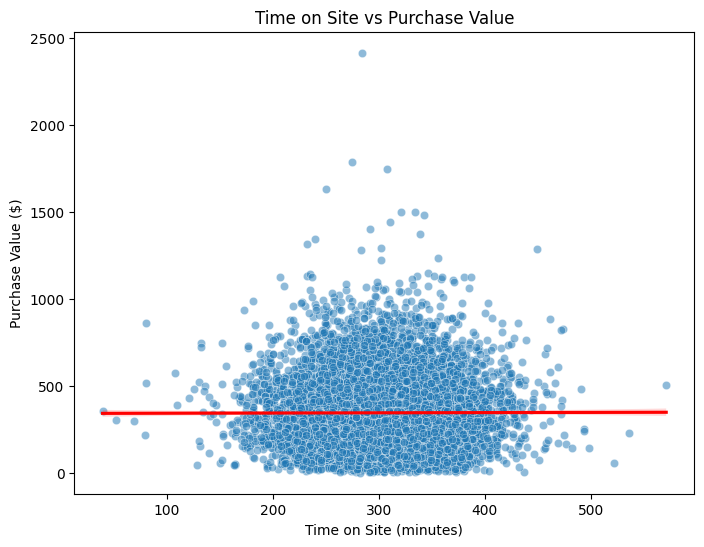

In [12]:
# scatter plot with regression line
plt.figure(figsize=(8,6))
sns.scatterplot(data=customer_data, x='time_on_site', y='purchase_value', alpha=0.5)
sns.regplot(data=customer_data, x='time_on_site', y='purchase_value', scatter=False, color='red')
plt.title('Time on Site vs Purchase Value')
plt.xlabel('Time on Site (minutes)')
plt.ylabel('Purchase Value ($)')
plt.show()

Q9. Is number of pages viewed correlated with purchase value?

Ho: There is no linear correlation between pages viewed and purchase value (ρ = 0)

H1 = There is a linear correlation between pages viewed and purchase value (ρ ≠ 0)

In [13]:
# Aggregate total spending per customer
total_spending = transactions.groupby('customer_id')['purchase_value'].sum().reset_index()

# Aggregate average pages viewed per customer
avg_pages = sessions.groupby('customer_id')['pages_viewed'].mean().reset_index()

# Merge aggregated data
customer_data = total_spending.merge(avg_pages, on='customer_id')

# Rename for clarity 
customer_data.columns = ['customer_id', 'total_spending', 'avg_pages_viewed']

# Pearson correlation
pearson_corr, pearson_p = pearsonr(
    customer_data['avg_pages_viewed'],
    customer_data['total_spending']
)

print(f"Pearson correlation coefficient: {pearson_corr:.5f}")
print(f"P-value: {pearson_p:.5f}")

alpha = 0.05
if pearson_p < alpha:
    print("Conclusion: Reject H0 → There is a statistically significant correlation.")
else:
    print("Conclusion: Fail to reject H0 → No significant correlation.")

Pearson correlation coefficient: 0.00044
P-value: 0.96552
Conclusion: Fail to reject H0 → No significant correlation.


Q10. Is time on site correlated with pages viewed?

H0: There is no linear correlation between time on site and pages viewed (ρ = 0)

H1: There is a linear correlation between time on site and pages viewed (ρ ≠ 0)

Pearson correlation coefficient: 0.005
P-value: 0.229
Conclusion: Fail to reject H0 → No significant correlation between time on site and pages viewed.


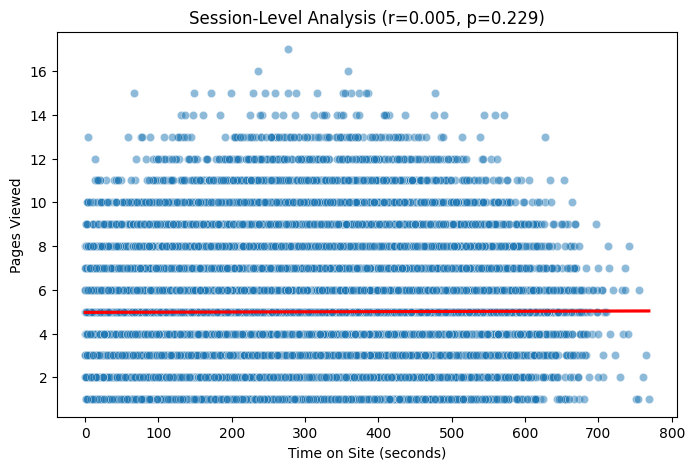

In [14]:
#session level
pearson_corr, pearson_p = pearsonr(sessions['time_on_site'], sessions['pages_viewed'])
print(f"Pearson correlation coefficient: {pearson_corr:.3f}")
print(f"P-value: {pearson_p:.3f}")

alpha = 0.05
if pearson_p < alpha:
    print("Conclusion: Reject H0 → Time on site and pages viewed are significantly correlated.")
else:
    print("Conclusion: Fail to reject H0 → No significant correlation between time on site and pages viewed.")

# Visualize the session-level relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(x='time_on_site', y='pages_viewed', data=sessions, alpha=0.5)
sns.regplot(x='time_on_site', y='pages_viewed', data=sessions, scatter=False, color='red')

plt.title(f'Session-Level Analysis (r={pearson_corr:.3f}, p={pearson_p:.3f})')
plt.xlabel('Time on Site (seconds)')
plt.ylabel('Pages Viewed')
plt.show()


The red line in the graph is almost completely flat. 
This tells a business: "Increasing the time a user spends on the site during a visit does not reliably increase the number of pages they look at."

### Challenges

C1. Explore whether high-spending customers behave differently in terms of session time.

Define “high spending” yourself.

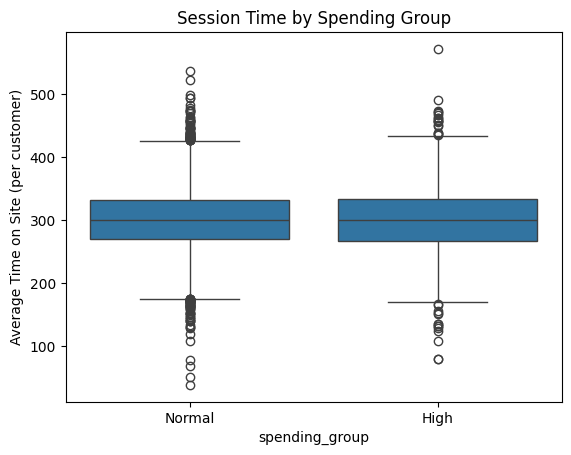

T-statistic: -0.1323
P-value: 0.89472
No strong evidence of difference


In [15]:
#Calculate total spending per customer 
total_spend = transactions.groupby('customer_id')['purchase_value'].sum().reset_index()

#Calculate average session time per customer 
avg_time = sessions.groupby('customer_id')['time_on_site'].mean().reset_index()

# merging the two summaries
customer_data = total_spend.merge(avg_time, on='customer_id')

#Defining High Spenders 
threshold = customer_data['purchase_value'].quantile(0.75)
customer_data['spending_group'] = customer_data['purchase_value'].apply(
    lambda x: 'High' if x >= threshold else 'Normal'
)

#T-Test 
high = customer_data[customer_data['spending_group'] == 'High']['time_on_site']
normal = customer_data[customer_data['spending_group'] == 'Normal']['time_on_site']
t_stat, p_value = ttest_ind(high, normal, equal_var=False)

#visual
sns.boxplot(x='spending_group', y='time_on_site', data=customer_data)
plt.title('Session Time by Spending Group')
plt.ylabel('Average Time on Site (per customer)')
plt.show()


print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05

if p_value < alpha:
    print("High spenders differ significantly from normal spenders")
else:
    print("No strong evidence of difference")




C2. Find a relationship (difference or correlation) that you believe is meaningful for business strategy.

Explain why.

In [22]:
# Merge tables on customer_id
st_merged = sessions.merge(transactions, on="customer_id", how="left")
conversion_rate = (
    sessions
    .groupby("traffic_source")["converted"]
    .mean()
)

avg_purchase = (
    st_merged
    .groupby("traffic_source")["purchase_value"]
    .mean()
)

summary = pd.concat([conversion_rate, avg_purchase], axis=1)
summary.columns = ["conversion_rate", "avg_purchase"]

r = summary["conversion_rate"].corr(summary["avg_purchase"])
print("Pearson r:", r)

print(avg_purchase)

Pearson r: -0.38076210305445723
traffic_source
direct     75.887188
email      75.769243
organic    75.462965
paid       75.568400
social     76.021318
Name: purchase_value, dtype: float64


Pearson r = −0.38. I examined the relationship between conversion rate and average purchase value across traffic sources 
because traffic source reflects marketing campaigns that management can influence. The negative correlation shows that sources 
generating more conversions do not necessarily produce higher-spending customers. This suggests that the marketing strategy should 
allocate the budget based on a combination of performance metrics, investing not only in sources with high conversion rates 
but also in those that attract customers with higher average purchase value, in order to maximize total revenue and profitability.

c3. Identify a statistically significant result that may not be practically meaningful.

Explain why statistical significance ≠ business importance.

To investigate the relationship between user engagement metrics, I compared the correlation between Time on Site and Pages Viewed 
at a different levels than question 10 (session level) the aggregated customer level.

Pearson correlation coefficient: 0.847
P-value: 0.000
Conclusion: Reject H0 → Time on site and pages viewed are significantly correlated.


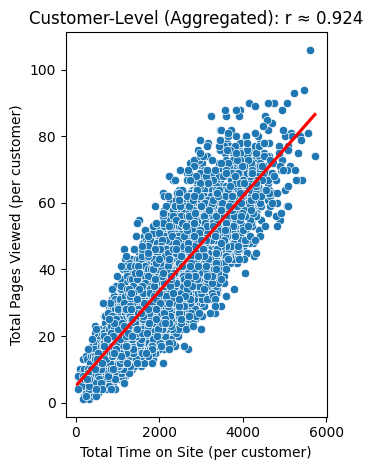

In [17]:
timeandpages_per_customer = sessions.groupby('customer_id').agg({
    'time_on_site': 'sum',     
    'pages_viewed': 'sum'      
}).reset_index()

pearson_corr, pearson_p = pearsonr(timeandpages_per_customer['time_on_site'], timeandpages_per_customer['pages_viewed'])
print(f"Pearson correlation coefficient: {pearson_corr:.3f}")
print(f"P-value: {pearson_p:.3f}")
alpha = 0.05
if pearson_p < alpha:
    print("Conclusion: Reject H0 → Time on site and pages viewed are significantly correlated.")
else:
    print("Conclusion: Fail to reject H0 → No significant correlation between time on site and pages viewed.")
#At the session level (Q10), time on site and pages viewed are uncorrelated (r = 0.005, p = 0.229).
#However, when aggregated per customer, total time and total pages viewed are strongly positively correlated (r = 0.924, p < 0.001).
#This difference arises because aggregation removes session-to-session variability and highlights overall customer behavior.

# scatter plot with regression line 
plt.subplot(1,2,2)
sns.scatterplot(
    x='time_on_site', 
    y='pages_viewed', 
    data=timeandpages_per_customer
)
# regression line
sns.regplot(
    x='time_on_site', 
    y='pages_viewed', 
    data=timeandpages_per_customer,
    scatter=False, color='red'
)
plt.title('Customer-Level (Aggregated): r ≈ 0.924')
plt.xlabel('Total Time on Site (per customer)')
plt.ylabel('Total Pages Viewed (per customer)')

plt.tight_layout()
plt.show()

Identifying the Practically Meaningless Result:
The customer-level correlation of r = 0.924 is a statistically significant result that lacks practical business meaning. While the p-value (< 0.001) suggests a nearly certain relationship, this result is primarily a byproduct of Aggregation Bias.By summing the data, we are no longer measuring the relationship between time and pages; we are measuring the activity level of the customer. 

Why Statistical Significance ≠ Business Importance

Statistical significance is a measure of certainty, not a measure of scale. A p-value only tells us how sure we are that a difference exists; 
it says nothing about how large or important that difference is. 

A manager should never make a decision based on a p-value alone without looking 
at the absolute difference and the cost-benefit ratio of taking action.

From the above analysis: 

•Share your 1 statistically significant result

•Share your 1 non-statistically significant result

•1 business interpretation

1. Statistically Significant Result Finding: Discount Usage vs. Purchase Value (p < 0.001). In Q2 we found a massive T-statistic of -29.98. 
This confirms that there is a definitive, non-random difference in spending behavior between those who use discounts and those who do not.
The Data: Discounted purchases averaged 64.48, while non-discounted purchases averaged 80.76.
"So What?": While discounts are excellent for driving volume (getting people to say "yes"), they reduse the average transaction value. 
This is a "real" statistical difference that management must account for when forecasting revenue.

2. Non-Statistically Significant Result Finding: Device Type vs. Conversion (p = 0.563). Despite the common assumption that desktop users convert 
at higher rates due to ease of use, our Chi-square test showed no meaningful relationship between the device a customer uses and their likelihood to buy.
The Data: Conversion rates across Desktop, Mobile, and Tablet were all within 0.3% of each other (roughly 13%).
"So What?": This "failed" result is actually a success for the technical team. It proves that the user experience is consistent across all platforms. 
There is no "broken" mobile checkout or "tablet-only" friction.

3. Business Interpretation: The "Quality vs. Quantity" Paradox (r = -0.38). The most strategic insight from our work is the moderate negative correlation between Conversion Rate and Average Purchase Value across traffic sources.
Strategic Insight: The "high-efficiency" channels (those that get people to click 'Buy' easily) are likely attracting bargain hunters or low-ticket buyers. 
Conversely, "high-value" channels (attracting big spenders) have a much harder time converting visitors.
The Takeaway: Management should stop judging marketing channels by a single metric. A "low-performing" channel with a 5% conversion rate might actually be more profitable than a "high-performing" channel with a 15% conversion rate if the average spend is significantly higher.

Final "Peer Review" Note: We also identified that Total Time and Total Pages (Q10/C3) are significantly correlated at the customer level (r = 0.924) but not the session level. 
This is the perfect example of why Business Strategy should be driven by Session Behavior (how people act now) rather than Aggregated Totals (which just measure how often they return).

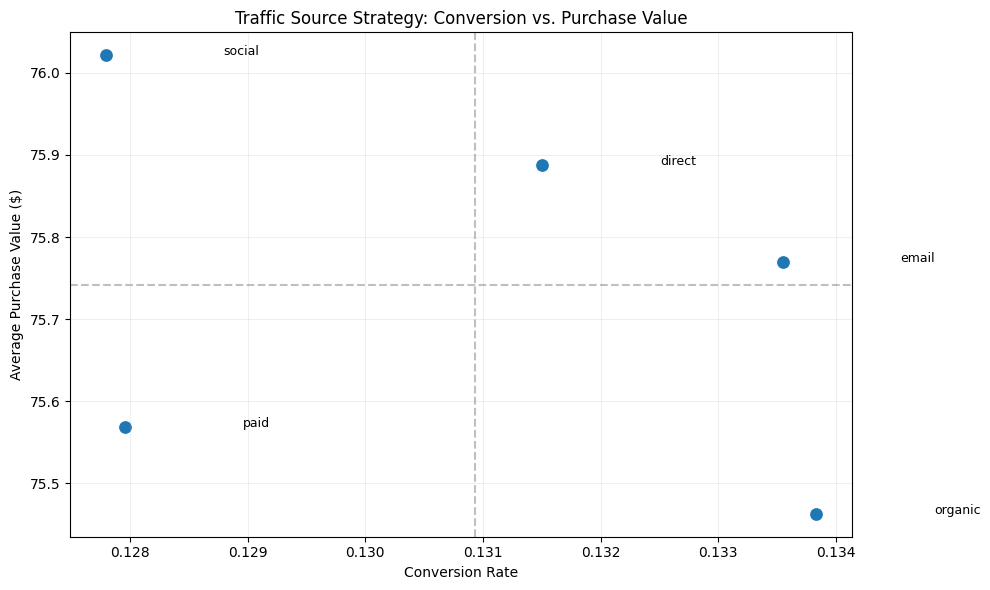

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=summary, x='conversion_rate', y='avg_purchase', s=100)

# FIX: Use .iloc to access values by their row position
for i in range(summary.shape[0]):
    plt.text(
        summary['conversion_rate'].iloc[i] + 0.001, 
        summary['avg_purchase'].iloc[i], 
        summary.index[i],
        fontsize=9
    )

# Add mean lines to create the Quadrants
plt.axvline(summary['conversion_rate'].mean(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(summary['avg_purchase'].mean(), color='gray', linestyle='--', alpha=0.5)

plt.title('Traffic Source Strategy: Conversion vs. Purchase Value')
plt.xlabel('Conversion Rate')
plt.ylabel('Average Purchase Value ($)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()




Executive Summary: Traffic Source

Direct & Email (Top Right): These usres are loyalists. They know what they want, they buy it, and they spend more. Strategy: Maintain and Reward.

Social (Top Left): These users browse high-end items but drop off before buying. Strategy: Use Retargeting ads to 'close the deal' and improve the checkout flow.

Organic (Bottom Right): These are 'Window Shoppers' who convert easily on low-cost items. Strategy: Implement 'Upsell' or 'Frequently Bought Together' prompts to raise their purchase value.

Paid (Bottom Left): This is 'Danger Zone.' We are paying for clicks that aren't spending much or converting well. Strategy: Audit your keywords—you might be bidding on terms that are too broad.

while the Pearson r is -0.38, the business importance of these quadrants is what matters most. Even if the correlation isn't "perfect," the clear separation of Social (High Value) from Organic (High Conversion) proves we need a multi-channel strategy.